# Prediction of solubility using Scikit-learn (linear regression)

Data from Delaney paper on predicting solubility, contains a set of compounds with SMILES and measured aqeuous solubility values. Molecular descriptors will be generated using RDKit, then Scikit-learn will be used to perform a linear regression and create a predictive model for aqeuous solubility.

J. Chem. Inf. Comput. Sci. 2004, 44, 1000-1005 by John S. Delaney

Data from: https://github.com/deepchem/deepchem/blob/master/datasets/delaney-processed.csv


### Load libraries:

In [1]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors

### Read data into DataFrame and generate RDKit molecule objects:

In [2]:
df = pd.read_csv('delaney-processed.csv')
df['mol'] = [Chem.MolFromSmiles(x) for x in df['smiles']] # List comprehension style

### Add calculated descriptor fields:

In [3]:
df['MolWt'] = df['mol'].apply(Descriptors.MolWt)
df['LogP'] = df['mol'].apply(Descriptors.MolLogP)
df['TPSA'] = df['mol'].apply(Descriptors.TPSA)
df['H_donors'] = df['mol'].apply(Descriptors.NumHDonors)
df['H_acceptors'] = df['mol'].apply(Descriptors.NumHAcceptors)
df['Rotatable_bonds'] = df['mol'].apply(Descriptors.NumRotatableBonds)

### Set up features and target parameter (measured solubility):

In [4]:
features = ['MolWt', 'LogP', 'TPSA', 'H_donors', 'H_acceptors', 'Rotatable_bonds']
x = df[features]
y = df['measured log solubility in mols per litre']

### Train/test split (80:20):

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### Perform linear regression and output coefficients:

In [6]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# Which descriptors matter and in which direction?
for name, coef in zip(features, model.coef_): # combines the features and their coefficients into a sequence of pairs (tuples), then loops through name and coef
    print(f"{name}:{coef:.3f}")

MolWt:-0.004
LogP:-0.928
TPSA:-0.016
H_donors:-0.087
H_acceptors:0.170
Rotatable_bonds:-0.000


* LogP is negative, consistent with more lipophillic molecules being less soluble.

### Measure error in predictions (R2 and RMSE):

In [7]:
from sklearn.metrics import r2_score, root_mean_squared_error
y_pred = model.predict(X_test) # prediction of solubility on X_test. X_test is the features of the 20% of samples that were withheld from the model
print(f"R2: {r2_score(y_test, y_pred)}") # y_test is the withheld known soubility values. Comparison with prediction
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}") # On average how far off are the predictions, in the actual units of the target?

R2: 0.7415823663951286
RMSE: 1.1052101032239467


* R2 is the fraction of the variation in solubility that is explained by our model (built using the features). It compares the spread of solubility values around their mean vs the residual errors between predicted and true values.
Typically 0 to 1 scale, but can go negative if model is worse than guessing the average. 0.7-0.9 is typical for a good prediction in a QSAR model like this.

* RMSE is the typical residual error. To avoid pos/neg errors canceling out, the residuals are squared (cancelling signs and disproportionately weighting big errors), then averaged, then rooted to undo the squared units.

### Plot of LogP vs Actual solubility:

<Axes: xlabel='measured log solubility in mols per litre', ylabel='LogP'>

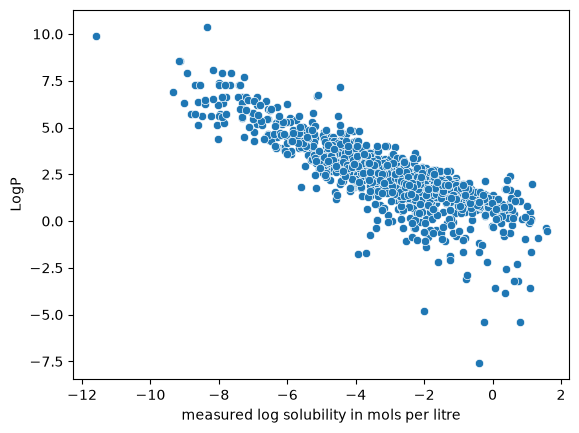

In [8]:
import seaborn as sns

sns.scatterplot(df, x='measured log solubility in mols per litre', y='LogP')

* Negative trend visible

### Generate results table:

In [9]:
results = X_test.copy()
results['Actual'] = y_test
results['Predicted'] = y_pred
results['Error'] = abs(results['Actual'] - results['Predicted'])

### Plot Actual vs Predicted solubility:

[Text(0.5, 0, 'Measured log solubility (mol/L)'),
 Text(0, 0.5, 'Predicted log solubility (mol/L)')]

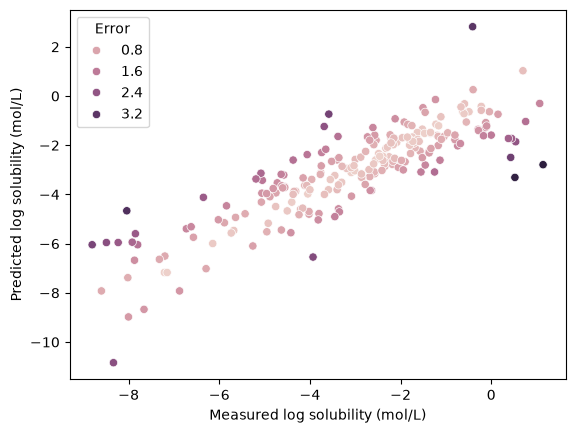

In [10]:
g = sns.scatterplot(results, x='Actual', y='Predicted', hue='Error')
g.set(xlabel = "Measured log solubility (mol/L)", ylabel="Predicted log solubility (mol/L)")

* Visually a good correlation between predicted and measured solublity

### Which compounds have the highest error in prediction?

In [11]:
df.loc[X_test.index, 'PredictedSolubility'] = y_pred
test_results = df.loc[X_test.index, ['Compound ID', 'smiles', 'LogP', 'measured log solubility in mols per litre', 'PredictedSolubility']]
test_results['AbsError'] = abs(test_results['measured log solubility in mols per litre'] - test_results['PredictedSolubility'])
test_results.sort_values("AbsError", ascending=False)


,Compound ID,smiles,LogP,measured log solubility in mols per litre,PredictedSolubility,AbsError
1064,vamidothion,CNC(=O)C(C)SCCSP(=O)(OC)(OC),1.9882,1.144,-2.790481,3.934481
292,Dimecron,CCN(CC)C(=O)C(=CCOP(=O)(OC)OC)Cl,2.3950,0.523,-3.309191,3.832191
845,Benzo(b)fluorene,C1c2ccccc2c3cc4ccccc4cc13,4.4110,-8.040,-4.664753,3.375247
298,Raffinose,OCC1OC(CO)(OC2OC(COC3OC(CO)C(O)C(O)C3O)C(O)C(O...,-7.5714,-0.410,2.818223,3.228223
796,Triethyl phosphate,CCOP(=O)(OCC)OCC,2.2040,0.430,-2.495265,2.925265
...,...,...,...,...,...,...
613,1-Nonanol,CCCCCCCCCO,2.7293,-3.010,-3.038888,0.028888
855,DDT,Clc1ccc(cc1)C(c2ccc(Cl)cc2)C(Cl)(Cl)Cl,6.4955,-7.150,-7.174171,0.024171
536,Santonin,CC3C2CCC1(C)C=CC(=O)C(=C1C2OC3=O)C,2.4196,-3.090,-3.109582,0.019582
959,2-Ethyl-2-hexanal,CCCC=C(CC)C=O,2.3218,-2.460,-2.448867,0.011133


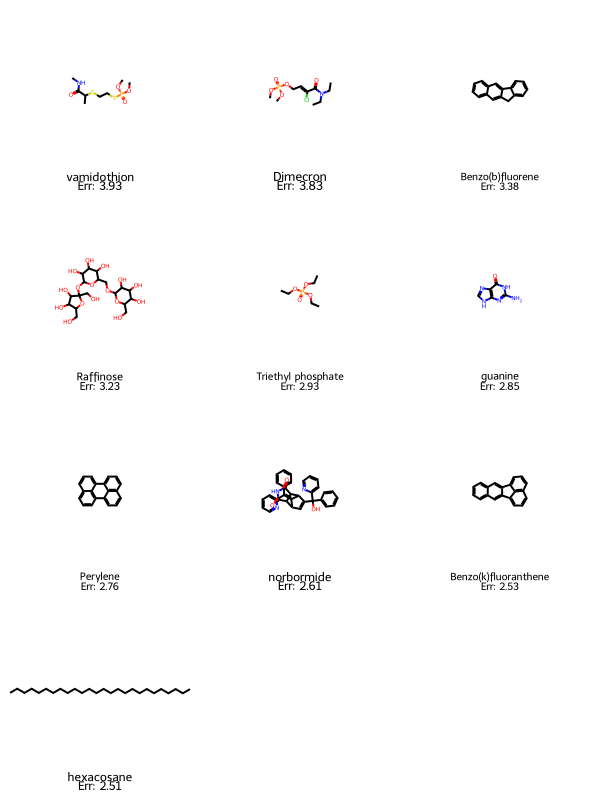

In [12]:
from rdkit.Chem import Draw

top_10 = test_results.sort_values("AbsError", ascending=False).head(10)

mols = [Chem.MolFromSmiles(smi) for smi in top_10.iloc[:, 1]]
legends = [f"{name}\nErr: {err:.2f}" for name, err in zip(top_10.iloc[:, 0], top_10["AbsError"])]

Draw.MolsToGridImage(mols, legends=legends)

### Is there higher error for lipophillic compounds?

Pearson coefficient of LogP vs AbsError: 0.074
Spearman coefficient of LogP vs AbsError: 0.155


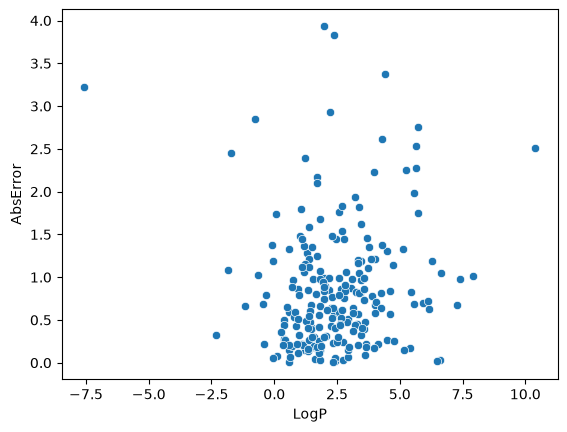

In [13]:
sns.scatterplot(test_results, x='LogP', y='AbsError')

pearson_corr = test_results['LogP'].corr(test_results['AbsError'], method='pearson')
print(f"Pearson coefficient of LogP vs AbsError: {pearson_corr:.3f}")

spearman_corr = test_results['LogP'].corr(test_results['AbsError'], method='spearman')
print(f"Spearman coefficient of LogP vs AbsError: {spearman_corr:.3f}")

* Only a weak correlation is observed between AbsError and LogP. The Spearman coefficient is higher than Pearson, indicating the relationship is non-linear. Is the error highest at extremes of the set's LogP range (U-shaped)?

### Is error highest at the extremes of LogP?

In [14]:
test_results['LogP_bin'] = pd.qcut(results['LogP'], q=5) # Bin LogP into 5 equal sized grroups
test_results.groupby('LogP_bin')['AbsError'].agg(['mean', 'median']) # Calculate the mean AbsError of each group

,mean,median
LogP_bin,,
"(-7.572, 1.132]",0.771532,0.566750
"(1.132, 1.823]",0.712534,0.484465
"(1.823, 2.69]",0.821574,0.636783
"(2.69, 3.647]",0.747782,0.733985
"(3.647, 10.389]",1.136645,0.976349


* Mean AbsError is notably higher in the top bin than the other four, which are broadly similar (0.71–0.82). Median AbsError shows a clearer trend, increasing fairly steadily from bin 2 through bin 5.
* The elevated error in bin 5 isn't purely an outlier artifact. Mean and median are reasonably close, suggesting a real shift in typical error rather than a few big misses dragging up the average.
* So solubility of the top 20% most lipophillic compounds were predicted more poorly than the rest of the set and there does appear to be a general increase in error with LogP (when median is used). Though could be possible that the actual solublity measurements were not that accurate, given some of those compounds will be virtually insoluble in water (e.g. LogP = 10)

In [15]:
logp_mean = test_results['LogP'].mean()
test_results['LogP_distance_from_center'] = (test_results['LogP'] - logp_mean).abs()

test_results[['LogP_distance_from_center', 'AbsError']].corr()


,LogP_distance_from_center,AbsError
LogP_distance_from_center,1.000000,0.240325
AbsError,0.240325,1.000000


* AbsError shows weak correlation with distance from the LogP center.

<Axes: xlabel='AbsError', ylabel='LogP_bin'>

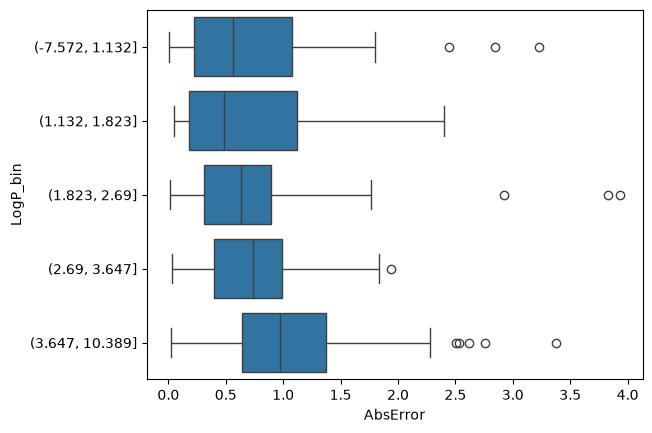

In [16]:
sns.boxplot(test_results, x='AbsError', y='LogP_bin')

* Box plot shows that visually the distributions are similar in the 5 bins, though the median in bin 5 is clearly highest.

### Summary

A linear regression on six RDKit-derived descriptors (molecular weight, LogP, TPSA, H-bond donors/acceptors, rotatable bonds) explains a reasonable share of the variance in measured aqueous solubility (R² = 0.74, RMSE = 1.11 log units), with LogP by far the dominant predictor. The negative coefficient of LogP matches the expected relationship between lipophilicity and solubility. Prediction error shows only a weak overall correlation with LogP, but binning compounds by LogP reveals that the most lipophilic 20% have a distinctly higher median error than the rest of the set. This may reflect a genuine limitation of a linear model at the extremes, though it could equally reflect lower experimental precision for very poorly soluble compounds, which are inherently harder to measure accurately.